# A Framework for Leveraging LLMs for Scene Analysis and Cognitive Processing

In [1]:
!pip install Levenshtein
!pip install nltk       

In [2]:
import os
HOME = os.getcwd()

os.chdir(HOME)
print(HOME)

/Users/berkayerkal/Downloads/human_patterns_exploration_v5/Untitled/human_patterns_exploration


In [3]:
HOME = os.getcwd()
os.chdir(HOME)

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")


In [4]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance
from src.core.ImageData import ImageData
from src.models.KG import KnowledgeGraph
import os
import pickle

from src.utils.data_utils import load_image_data

import pandas as pd
pd.set_option('display.max_rows', None)

import pandas as pd  



[nltk_data] Downloading package punkt to
[nltk_data]     /Users/berkayerkal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/berkayerkal/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/berkayerkal/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/berkayerkal/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/berkayerkal/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


NLTK data downloaded successfully!


### Checking the bounding boxes for all participants

In [5]:
IMG_ID = 20
IMG_TYPE = "unexp"
llm_provider = "openai"

# load image
IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")
image_data = load_image_data(IMG_PATH, IMG_TYPE, target = None)


# load masks
masks_path_dir = os.path.join(RESULTS_DIR, "Masks", "BestMask")
image_data.load_img_masks( masks_path_dir, part_id=None )
print(f"Loaded a total of {len(image_data.masks)} Masks for IMG {image_data.ID}_{image_data.img_type}")

Loaded a total of 180 Masks for IMG 20_unexp


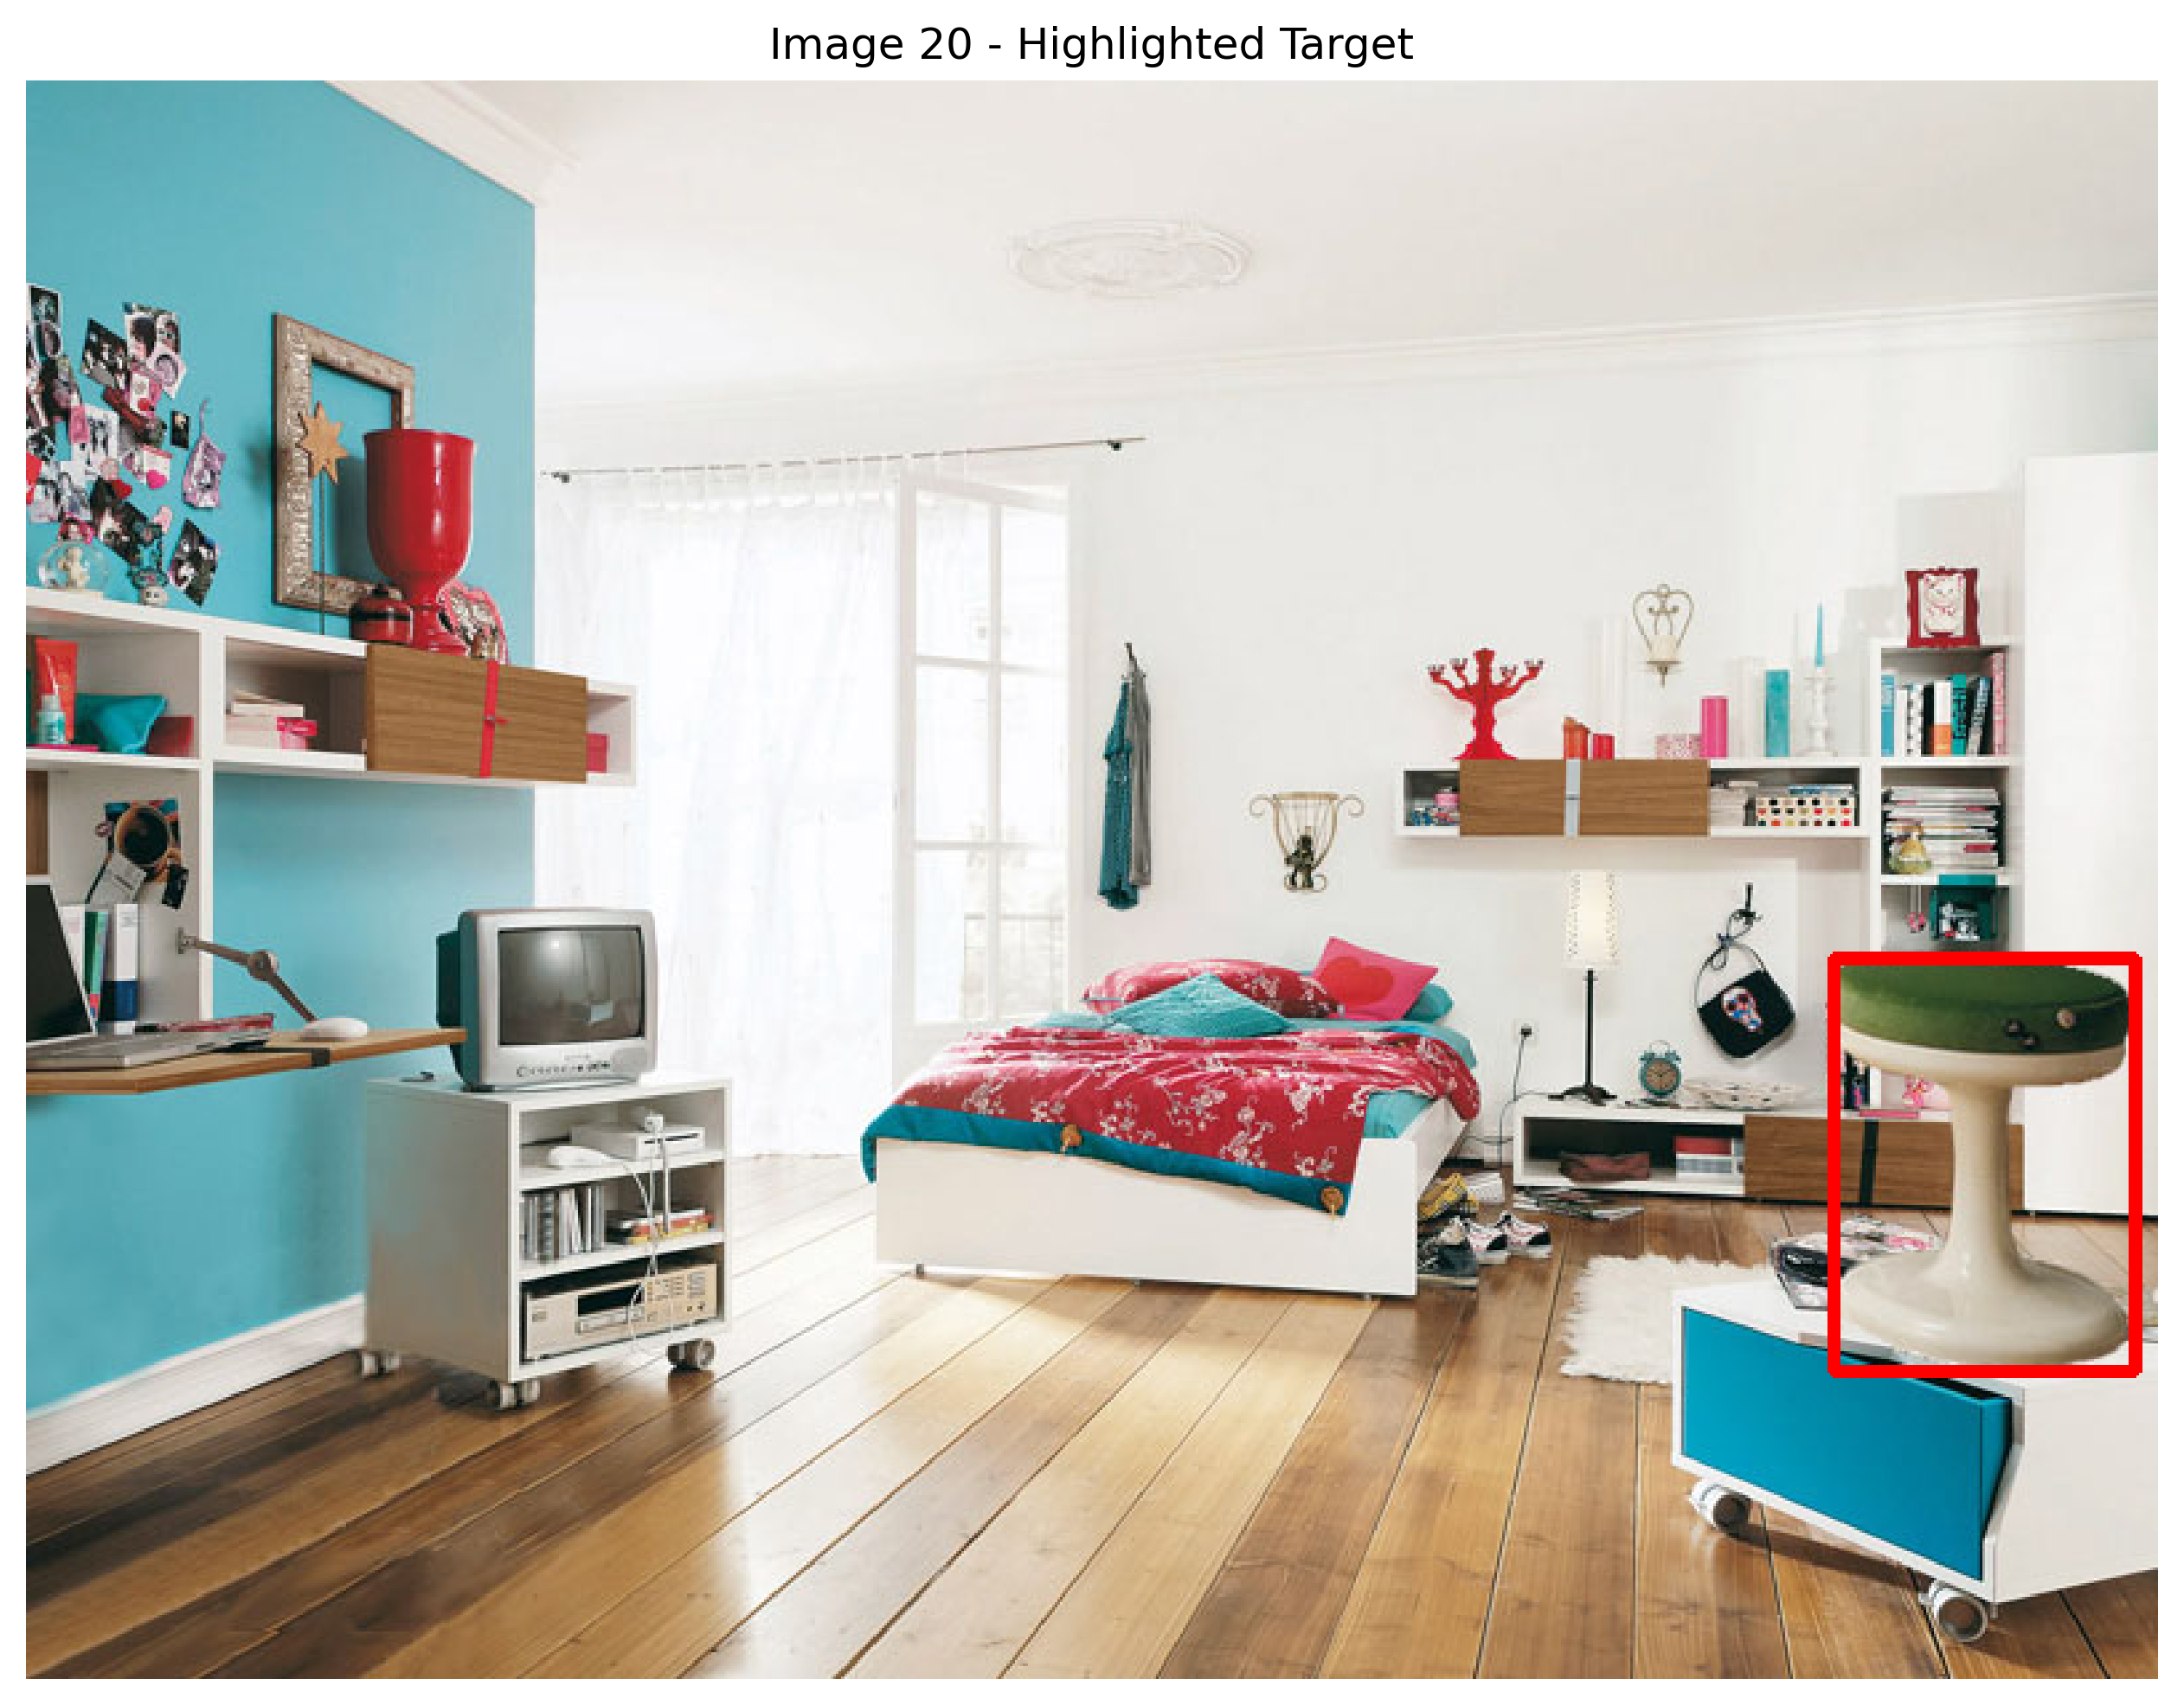

array([[[ 83, 167, 178],
        [ 82, 166, 177],
        [ 81, 165, 176],
        ...,
        [220, 216, 207],
        [220, 216, 207],
        [220, 216, 207]],

       [[ 82, 166, 177],
        [ 81, 165, 176],
        [ 80, 164, 175],
        ...,
        [220, 216, 207],
        [220, 216, 207],
        [220, 216, 207]],

       [[ 80, 164, 175],
        [ 80, 164, 175],
        [ 80, 164, 175],
        ...,
        [219, 215, 206],
        [220, 216, 207],
        [220, 216, 207]],

       ...,

       [[151, 109,  71],
        [156, 117,  78],
        [160, 122,  86],
        ...,
        [158, 111,  65],
        [158, 112,  63],
        [160, 114,  65]],

       [[158, 119,  86],
        [150, 114,  82],
        [138, 103,  73],
        ...,
        [160, 113,  67],
        [160, 114,  65],
        [160, 114,  65]],

       [[130,  95,  65],
        [113,  79,  51],
        [ 96,  65,  37],
        ...,
        [162, 115,  69],
        [165, 119,  70],
        [163, 117,  68]]

In [6]:
import os
import pandas as pd

# 1. point this at your real CSV
CSV_PATH = "/Users/berkayerkal/Downloads/human_patterns_exploration_v5/Untitled/" \
           "human_patterns_exploration/data/targetnames/imgtargetnames.csv"

# 2. load it once
targets_df = pd.read_csv(CSV_PATH)


# 3. (optional) normalize the column names to make lookups easier
targets_df.columns = (
    targets_df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
)

# 4. filter to just your image
match = (
    (targets_df["img_id"]   == IMG_ID) 
)
if not match.any():
    raise KeyError(f"No entry for IMG_ID={IMG_ID}, IMG_TYPE='{IMG_TYPE}' in targets CSV")

row = targets_df.loc[match].iloc[0]

# 5. assign into your ImageData instance
image_data.target = [
    row["x_min"],
    row["x_max"],
    row["y_min"],
    row["y_max"],
]

# 6. visualize
image_data.highlight_target()


In [7]:
image_data.get_scene_masks( sim_threshold= 0.9)


Plural/duplicate pairs found: []
Final unique labels: ["Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}"]


{"Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}": [0,
  60,
  0,
  198]}

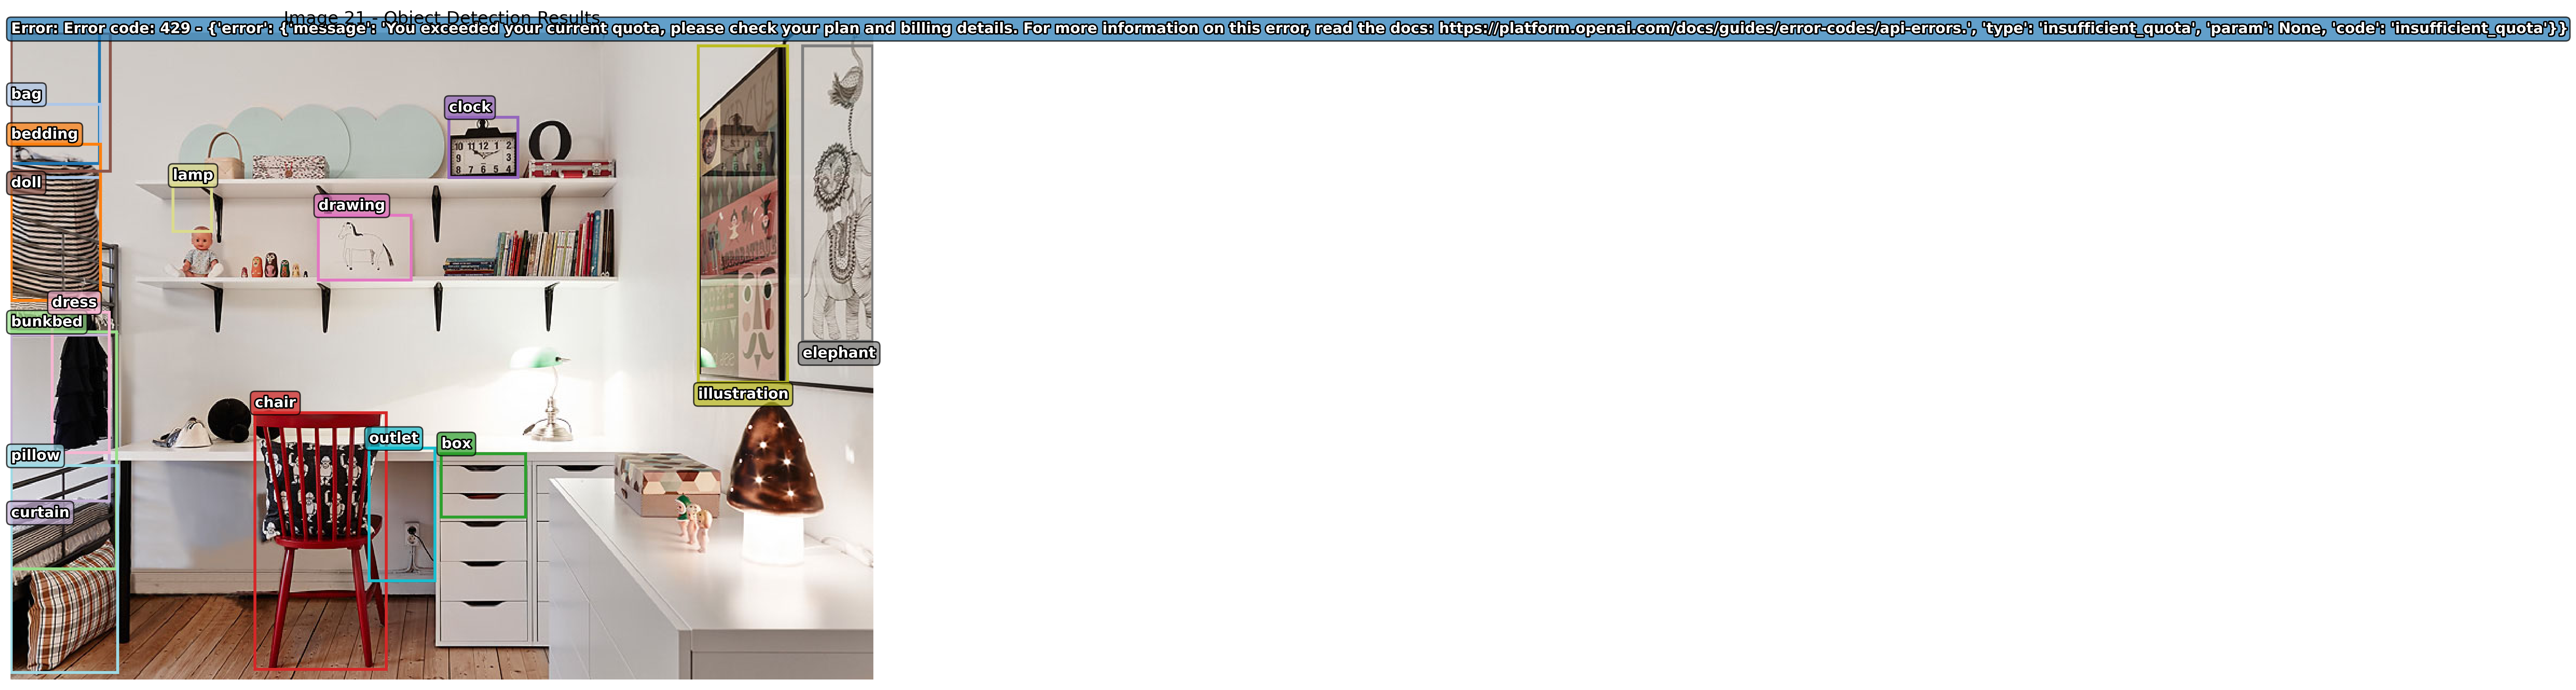

In [8]:
image_data.plot_mask_labels(  );

### Checking the bounding boxes for 1 participant only

In [ ]:
IMG_ID = 2
IMG_TYPE = "unexp"
llm_provider = "openai"

# load image
IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")
image_data = load_image_data(IMG_PATH, IMG_TYPE)



##masks_path_dir = os.path.join(RESULTS_DIR, "Masks", "BestMask")
##image_data.load_img_masks( masks_path_dir, part_id="5" )        # change here
##print(f"Loaded a total of {len(image_data.masks)} Masks for IMG {image_data.ID}_{image_data.img_type}")

Loaded a total of 2 Masks for IMG 2_unexp


In [9]:
image_data.get_scene_masks()


Plural/duplicate pairs found: []
Final unique labels: ["Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}", 'basket', 'bowl', 'calendar', 'crib', 'curtains', 'ottoman', 'pouf', 'shelf']


{"Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}": [73,
  183,
  26,
  259],
 'basket': [97, 211, 255, 303],
 'bowl': [97, 211, 255, 303],
 'calendar': [239, 295, 299, 416],
 'crib': [74, 290, 281, 352],
 'curtains': [82, 183, 113, 275],
 'ottoman': [97, 211, 255, 302],
 'pouf': [250, 335, 406, 497],
 'shelf': [452, 500, 363, 417]}

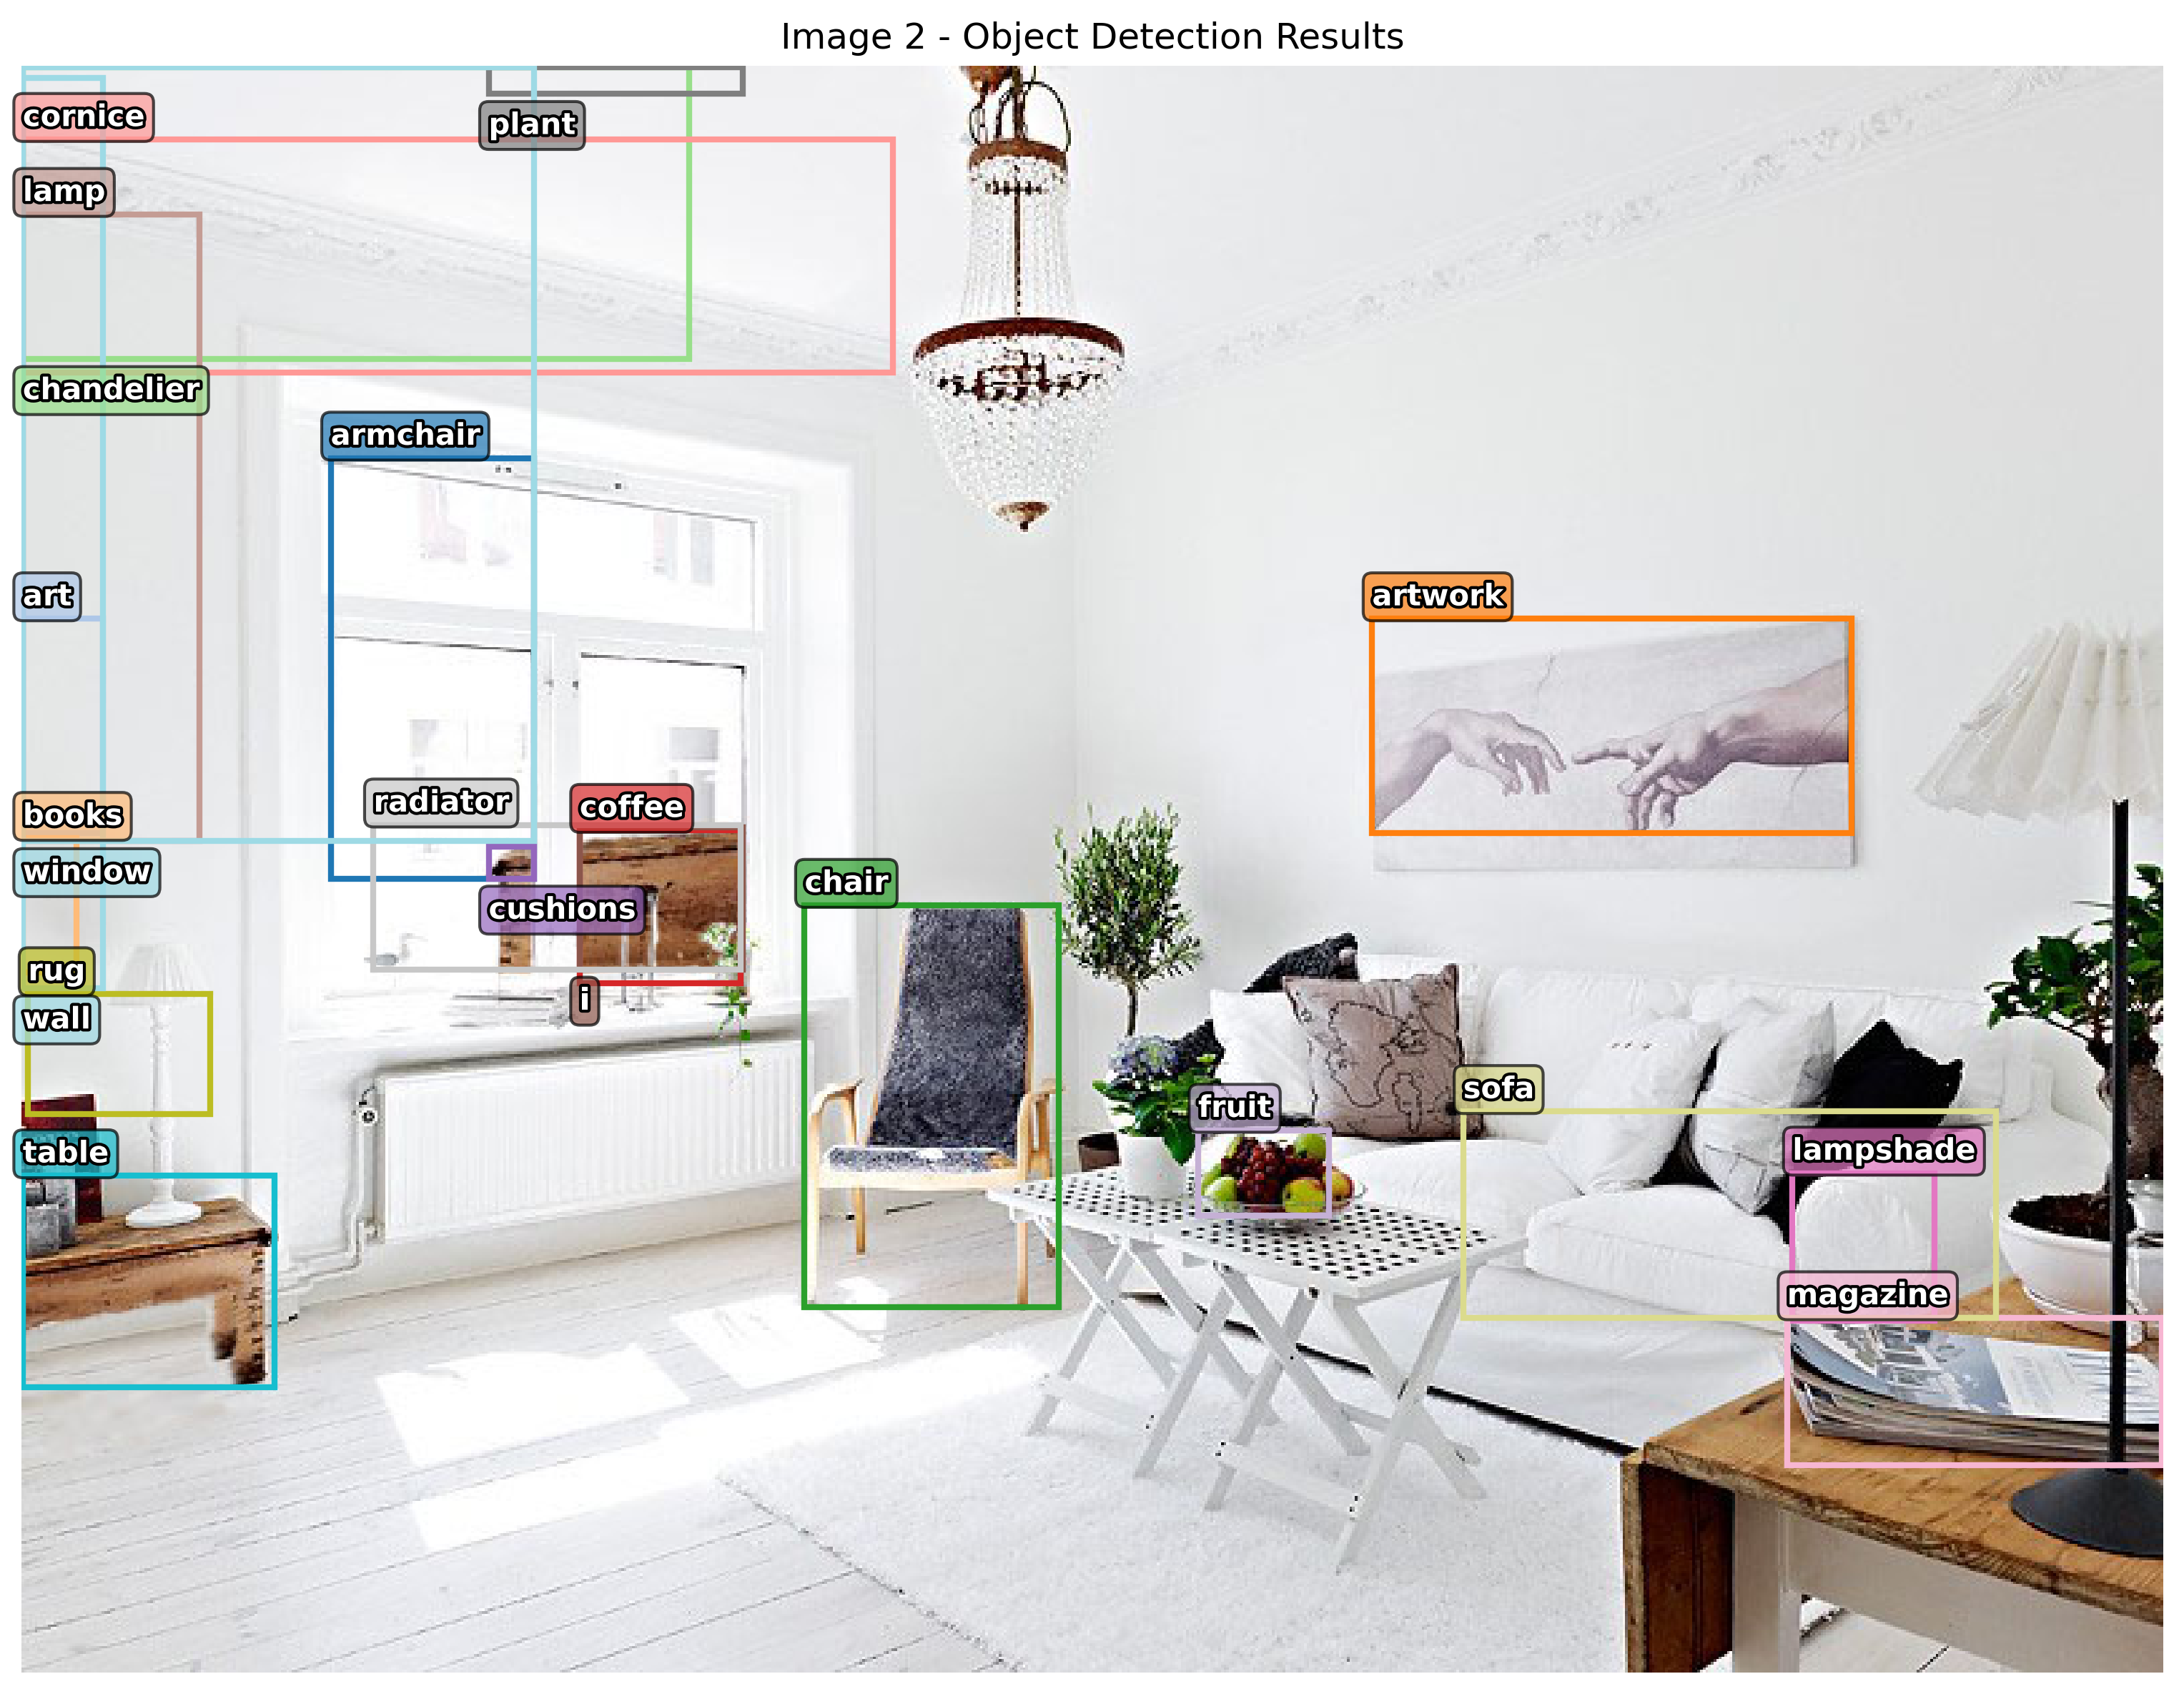

In [11]:
image_data.plot_mask_labels(  );

### KG

In [8]:
# call the KG builder
llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
KG = KnowledgeGraph(llm, image_data, sim_threshold=0.9)

Disambiguating scene masks...
  -> Lemma match! Removing 'curtain', keeping 'curtains'

Plural/duplicate pairs found: [('curtain', 'curtains', 'kept: curtains')]
Final unique labels: ["Error: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}", 'basket', 'bowl', 'calendar', 'crib', 'curtains', 'ottoman', 'pouf', 'shelf']


Processing knowledge graph for image 19


Generating triples for iteration 1...
Scene description completed in 11.96 seconds
Text query completed in 10.04 seconds

Total triples generated: 38


Generating triples for iteration 2...
Scene description completed in 13.30 seconds
Text query completed in 6.55 seconds

Total triples generated: 30


Generating triples for iteration 3...
Scene description completed in 13.31 seconds
Text query completed in 4.71 seconds

Total triples generated: 29

Generated triples: 97
Generated triples after removing duplicates:  62
Professional knowledge graph saved to outputs/KnowledgeGraph/19_knowledge_graph_professional.png
PDF version saved to outputs/KnowledgeGraph/19_knowledge_graph_professional.pdf


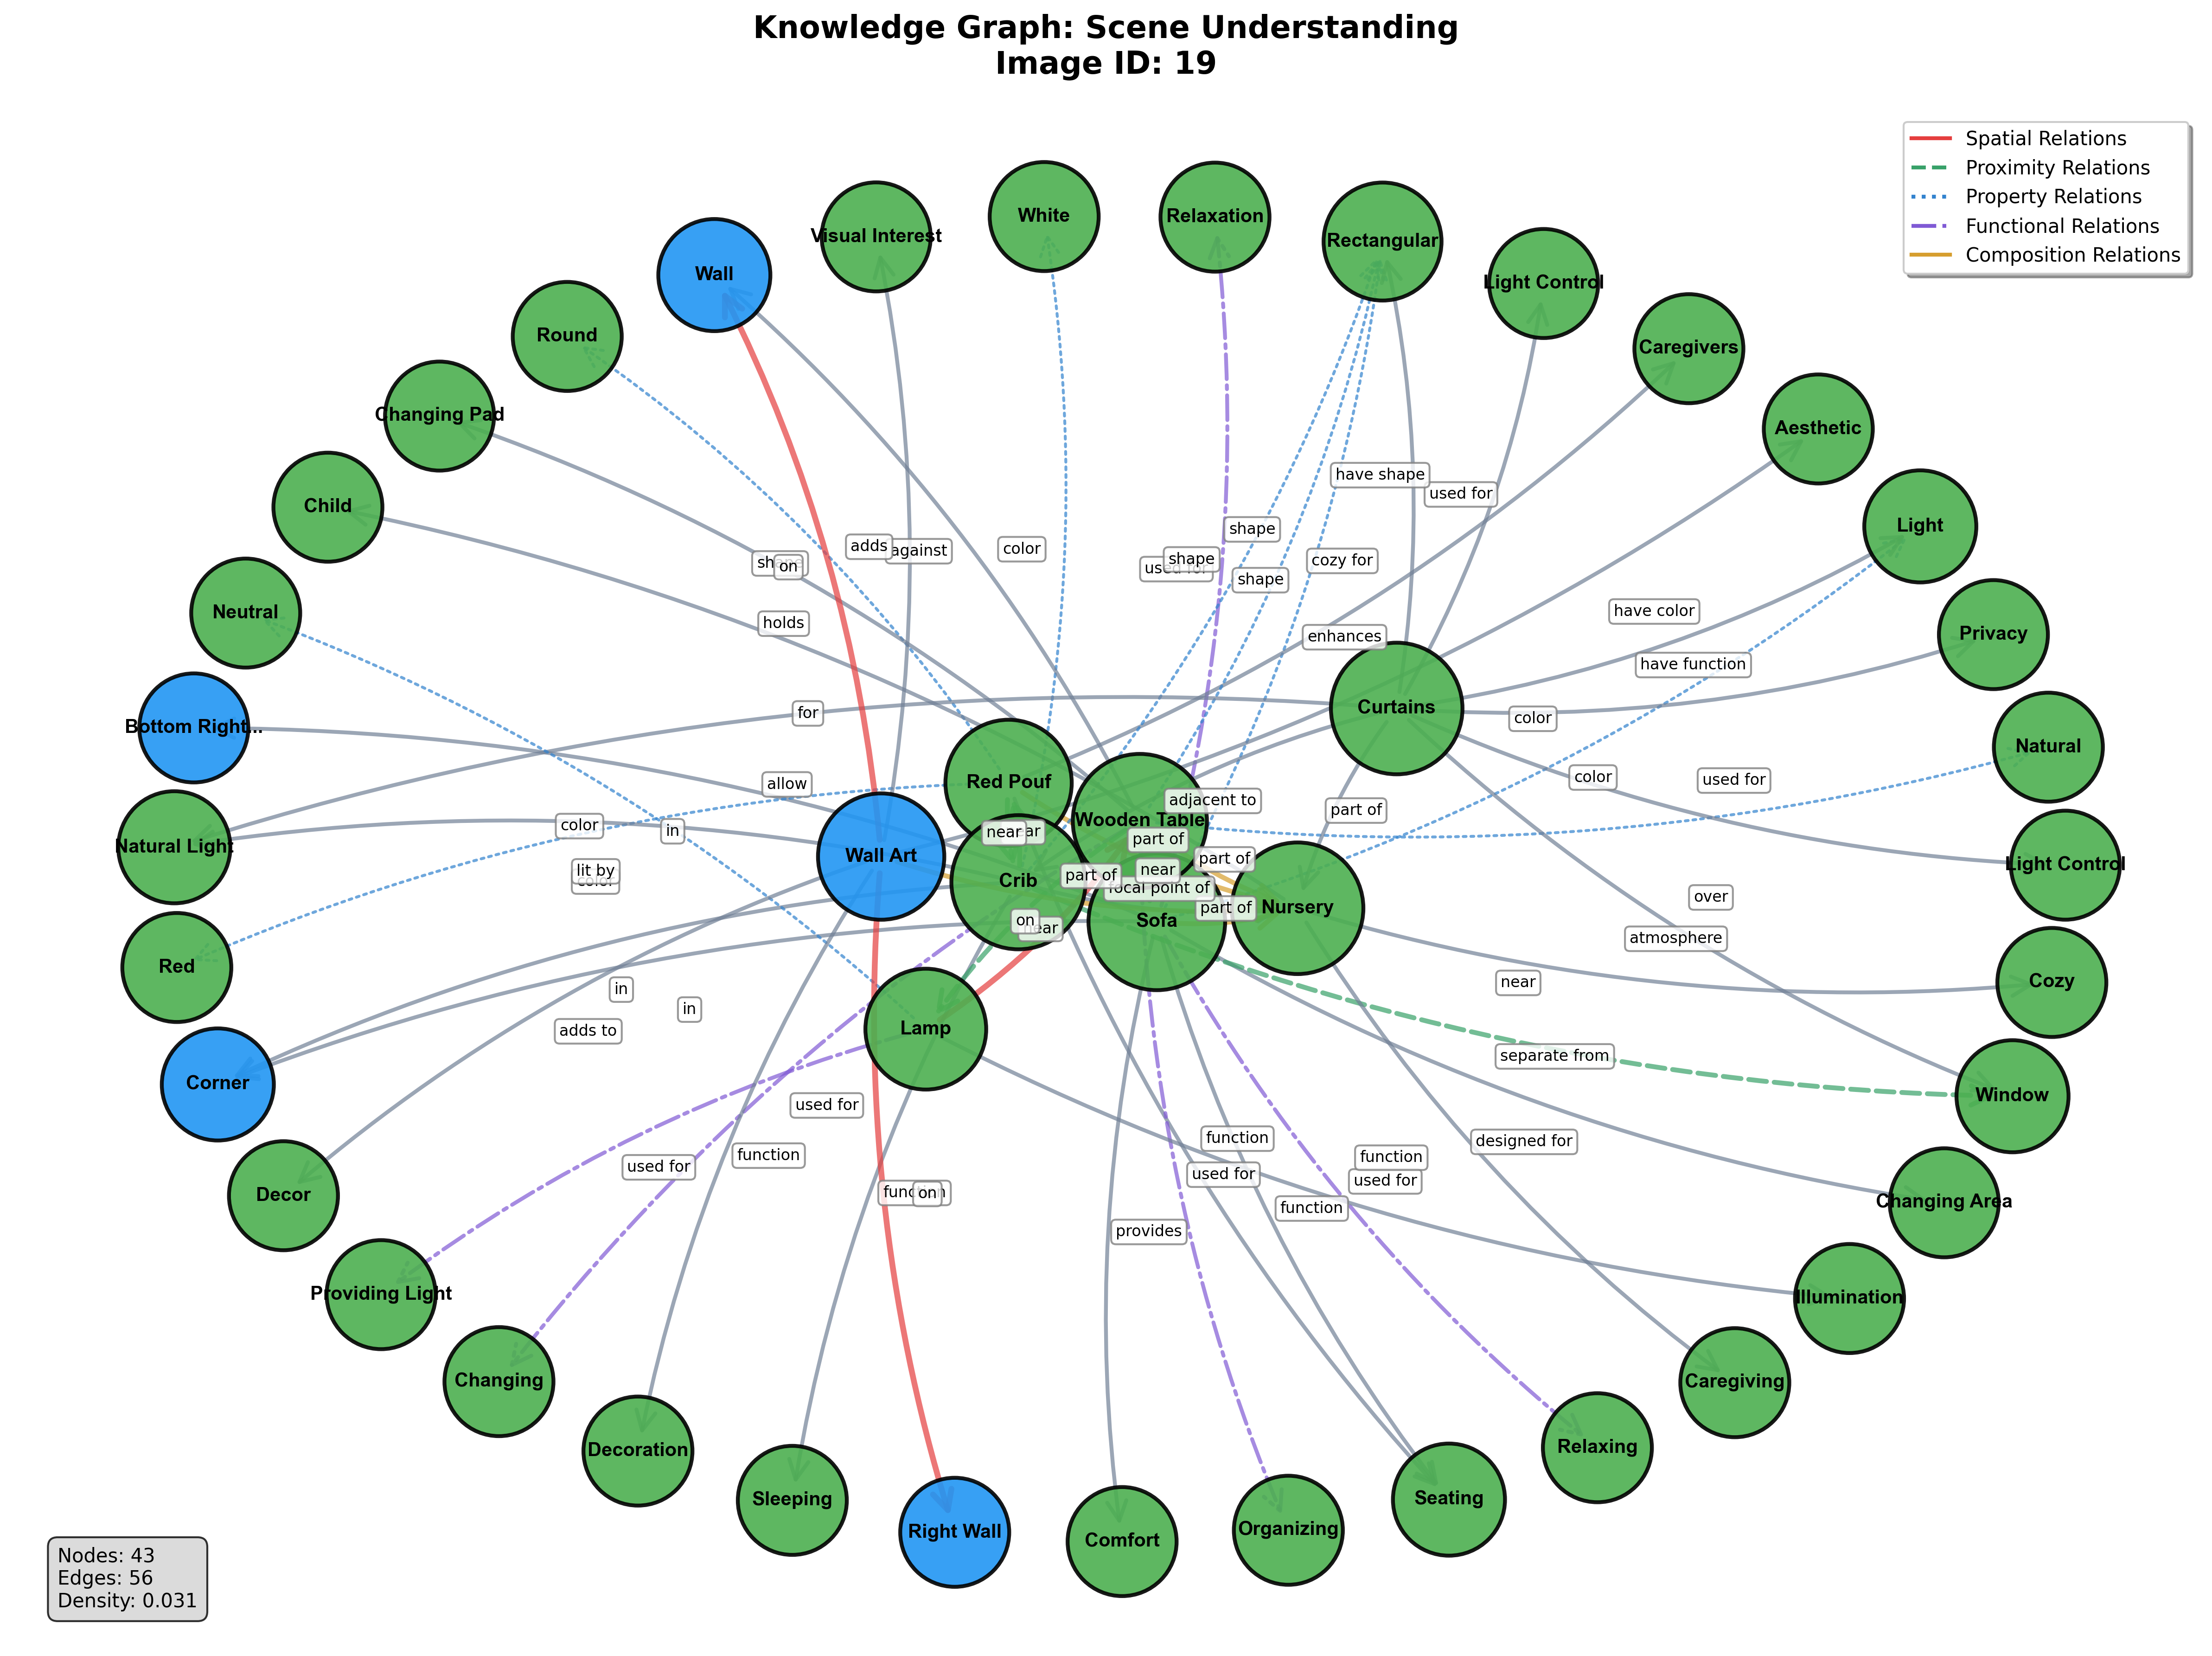

Relationship matrix saved to outputs/KnowledgeGraph/knowledge_matrices/IMG_19_unexp_knowledge_matrix.png


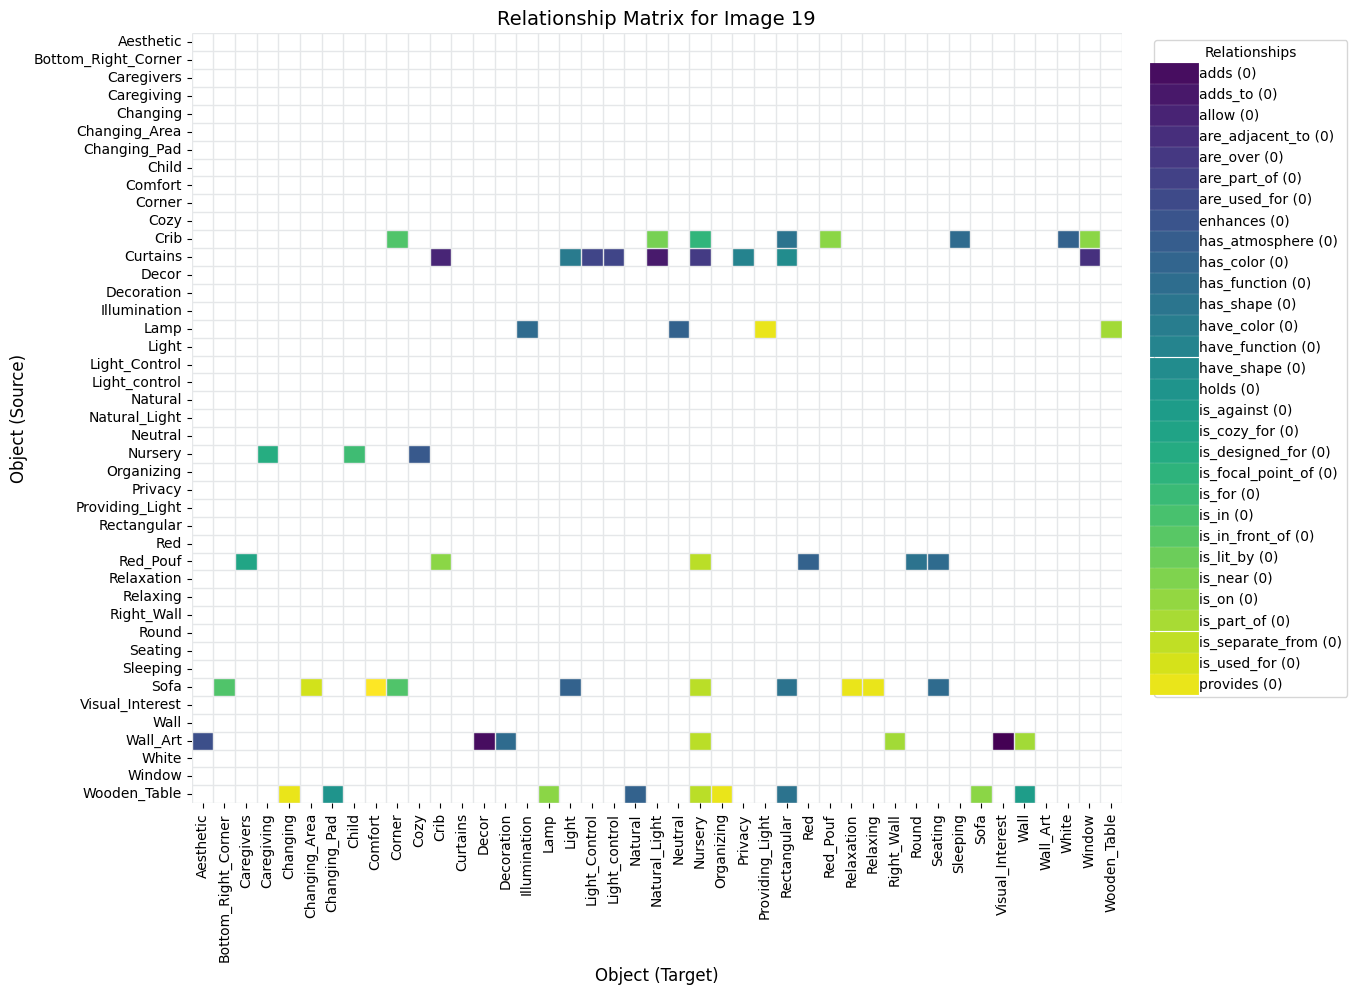

Adjacency matrix saved to outputs/KnowledgeGraph/knowledge_matrices/IMG_19_unexp_adjacency_matrix.csv


In [9]:
results = KG.process_image_complete( num_iter=3, debug=False)

In [17]:

# loading a saved KG
llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
KG2 = KnowledgeGraph(llm, image_data)
KG2.load_state(filepath = "outputs/KnowledgeGraph/IMG_15_unexp_knowledge_graph.pkl")

Disambiguating scene masks...
  -> Lemma match! Removing 'books', keeping 'book'
  -> Lemma match! Removing 'bookshelves', keeping 'bookshelf'
  -> Lemma match! Removing 'pillows', keeping 'pillow'

Plural/duplicate pairs found: [('book', 'books', 'kept: book'), ('bookshelf', 'bookshelves', 'kept: bookshelf'), ('pillow', 'pillows', 'kept: pillow')]
Final unique labels: ['art', 'artwork', 'basket', 'book', 'bookshelf', 'chandelier', 'coffee', 'fireplace', 'globe', 'lamp', 'lampshade', 'painting', 'pillow', 'plant', 'sculpture', 'sofa', 'soil', 'table', 'vase']


Professional knowledge graph saved to outputs/KnowledgeGraph/18_knowledge_graph_professional.png
PDF version saved to outputs/KnowledgeGraph/18_knowledge_graph_professional.pdf


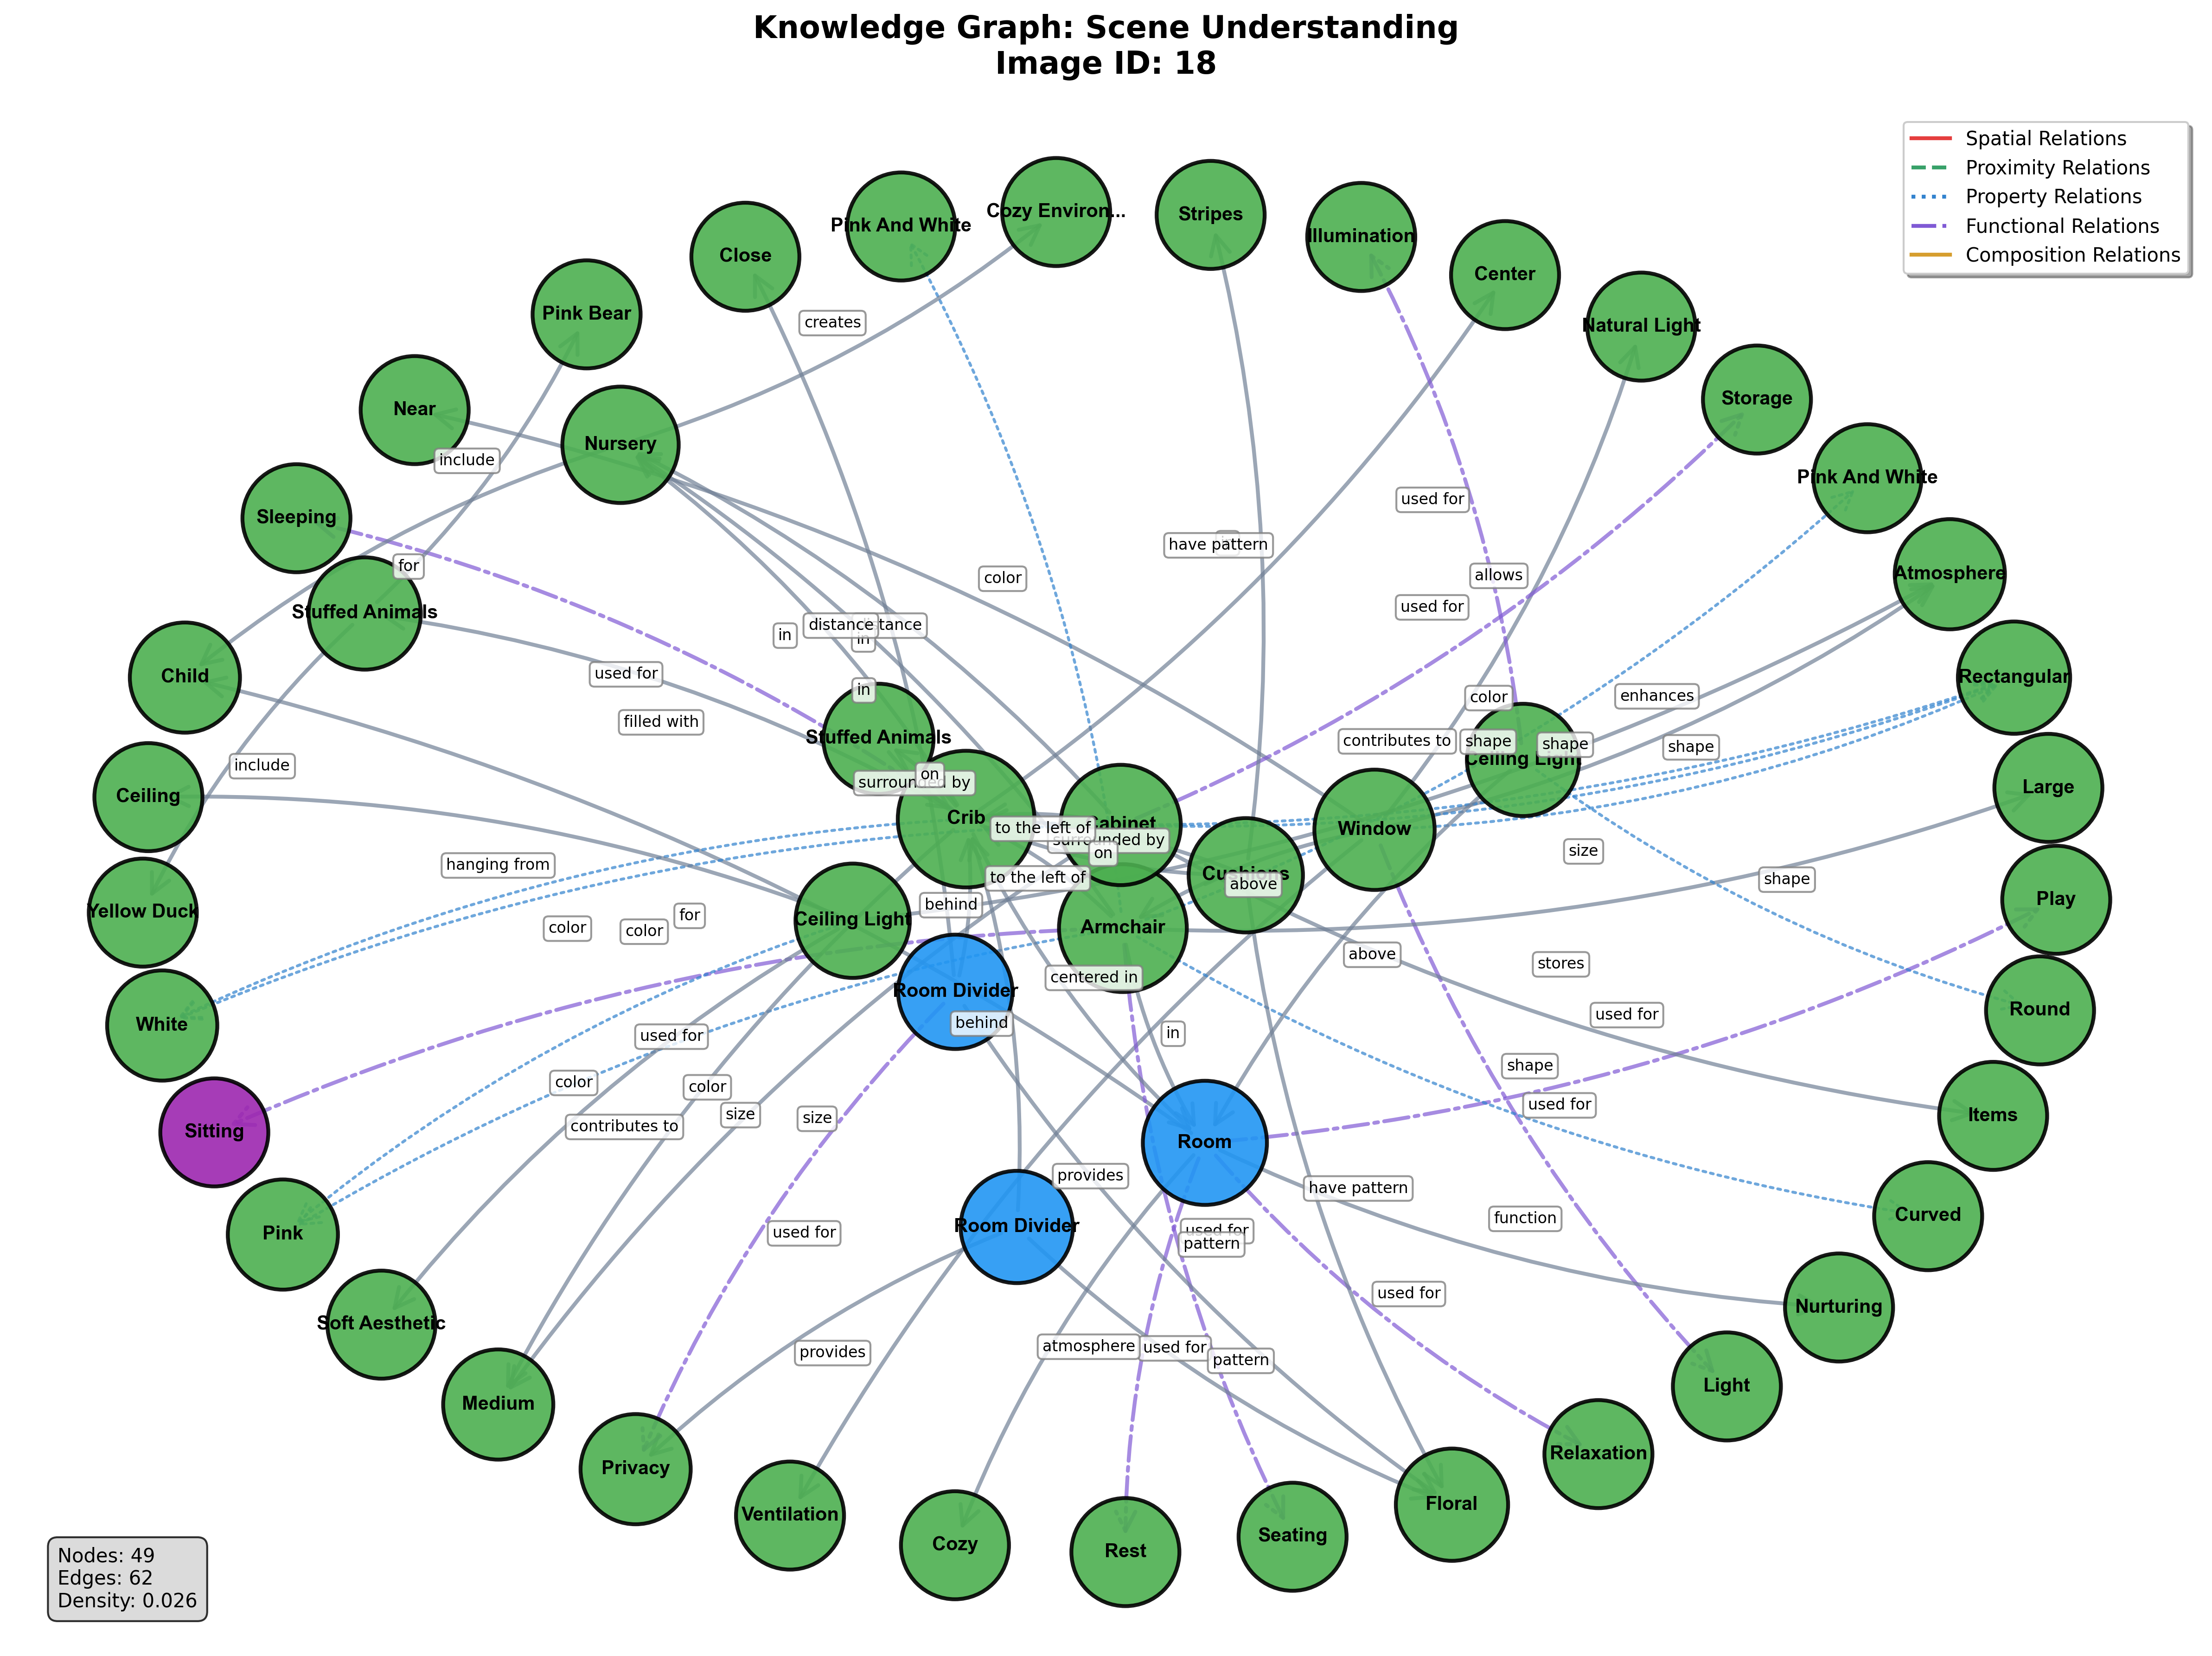

In [18]:
KG2.plot_knowledge_graph()

In [17]:
# this is part of what the KG.process_image_complete( num_iter=3, debug=False) function is doing.

# running this 3x so we can get a more enriched KG
all_triples = []
for i in range(3):

    print(f"Generating triples for iteration {i + 1}...")
    triples_raw = KG.generate_triples(debug=False)  
    triples_cleaned = KG.clean_triples_text(triples_raw)
    lines = triples_cleaned.strip().split('\n')
    print("\nTotal triples generated:", str(len(lines)))

    for line in lines:
        # Remove parentheses and spaces, then split by comma
        triple = tuple(item.strip().replace('(', '').replace(')', '') for item in line.split(','))
        all_triples.append(triple)

print("\nGenerated triples:", str(len(all_triples)))
# Remove duplicates
triples_final = list(set(all_triples))
print("Generated triples after removing duplicates: ", str(len(triples_final)))

Generating triples for iteration 1...
Scene description completed in 11.86 seconds
Text query completed in 6.96 seconds

Total triples generated: 30
Generating triples for iteration 2...
Scene description completed in 13.42 seconds
Text query completed in 6.12 seconds

Total triples generated: 33
Generating triples for iteration 3...
Scene description completed in 12.60 seconds
Text query completed in 8.44 seconds

Total triples generated: 36

Generated triples: 99
Generated triples after removing duplicates:  67
